# **Convolutional Neural Networks**  
Reference Material:
1. MNIST Digit Dataset : http://yann.lecun.com/exdb/mnist/

2. CNN : https://towardsdatascience.com/a-guide-to-convolutional-neural-networks-from-scratch-f1e3bfc3e2de

3. CNN pytorch: https://www.kaggle.com/code/sdelecourt/cnn-with-pytorch-for-mnist

4. CNN pytorch: https://nextjournal.com/gkoehler/pytorch-mnist (The below code is taken from here.)

#**Problem 1** : Demonstrate Image Classification using CNNs on MNIST Handwritten Digit Recognition dataset
Observations to be demonstrated:
1. Show image classification using CNN.
2. Demonstrate the translation invariant property of pooling layer (can choose two images, from which one is translated and show the output of pooling layer is near to identical for both the images).
3. Show that CNN used fewer number of parameters.

In [ ]:
import numpy as np
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Data Preparation

In [ ]:
(x_train, y_train), (x_test, y_test)=tf.keras.datasets.mnist.load_data(path="mnist.npz")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def select_data(cl,x_train, y_train,x_test, y_test,lab):
  id_tr=np.where(y_train==cl)
  id_te=np.where(y_test==cl)
  print(id_tr[0])
  tr_lab=y_train[id_tr[0]]
  tr_lab=np.tile(lab,tr_lab.shape)
  te_lab=y_test[id_te[0]]
  te_lab=np.tile(lab,te_lab.shape)
  tr_d=x_train[id_tr[0],:,:]
  te_d=x_test[id_te[0],:,:]
  tr_d = tr_d.astype('float32')
  tr_d /= 255
  te_d=te_d.astype('float32')
  te_d /=255
  return tr_d,te_d,tr_lab,te_lab



In [ ]:
cl=[3,5]

# for class 1
tr_d1,te_d1,tr_lab1,te_lab1=select_data(cl[0],x_train, y_train,x_test, y_test,0)
# for class 2
tr_d2,te_d2,tr_lab2,te_lab2=select_data(cl[1],x_train, y_train,x_test, y_test,1)


data_tr=np.concatenate((tr_d1,tr_d2))
data_ts=np.concatenate((te_d1,te_d2))

lab_tr=np.concatenate((tr_lab1,tr_lab2))
lab_ts=np.concatenate((te_lab1,te_lab2))

[    7    10    12 ... 59978 59980 59996]
[    0    11    35 ... 59968 59993 59997]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import DataLoader

In [ ]:
## data loader

class Dataset(Data.Dataset):
    def __init__(self, feat=None, label=None, context=None):
        super(Dataset, self).__init__()
        self.feat = feat
        self.label = label

    def __len__(self):
        leng=self.feat.shape[0]
        return int(leng)

    def __getitem__(self, index):
        #print(index)
        vector = self.feat[index,:,:]
        lab=np.asarray(self.label[index])
        #vector[-1] = self.classNum
        feat = torch.from_numpy(vector)
        label= torch.from_numpy(lab)
        return feat, label.float()


In [ ]:
data_trn= Dataset(feat=data_tr,label=lab_tr)
train_loader = DataLoader(data_trn,shuffle=True, batch_size=64, pin_memory=True, num_workers=1)

data_tst = Dataset(feat=data_ts, label=lab_ts)
test_loader = DataLoader(data_tst,shuffle=True, batch_size=64, pin_memory=True, num_workers=1)

In [ ]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([64, 28, 28])

## Taking two classes
 - Images of five: label 1
 - Images of three: label 0

 Note: You can take any other digits as well.

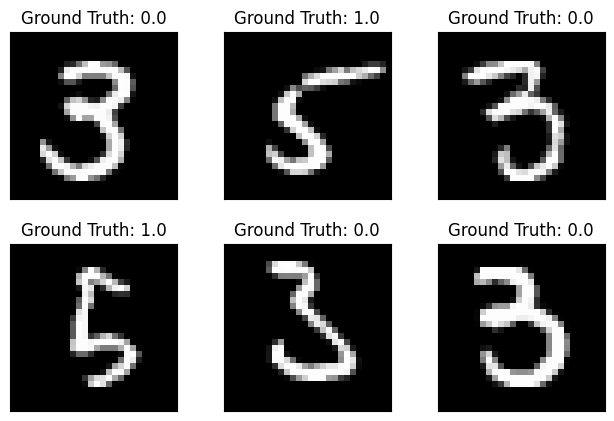

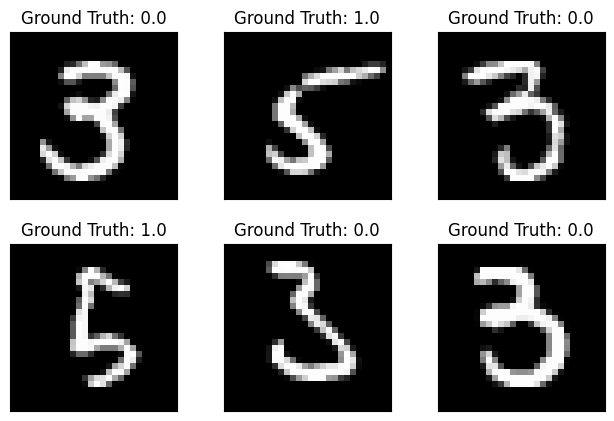

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [ ]:
n_epochs = 10
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

# **Two Class Classification**
Comparison between FFNN with one hidden layer and CNN with one convolution layer


# FFNN

In [ ]:
# Write your code here to train FFNN

### Test result using FFNN

In [ ]:
# Write your code here to test FFNN

# CNN

In [ ]:
# Write your code here to train CNN

### Test result using CNN

In [ ]:
# Write your code here to test CNN

# T-SNE plot obtained from output of hidden layers
This is to check how well both networks have learnt the distribution

### FFNN

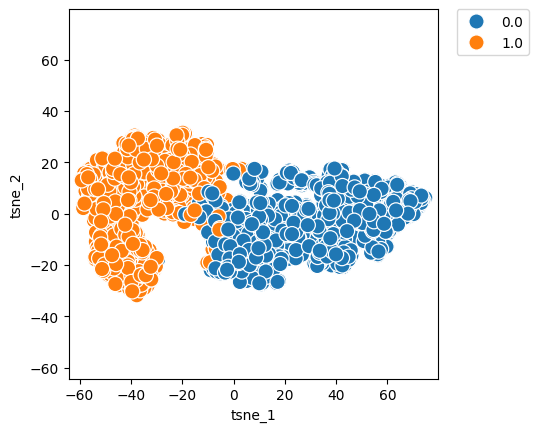

In [ ]:
# Write code here

### CNN

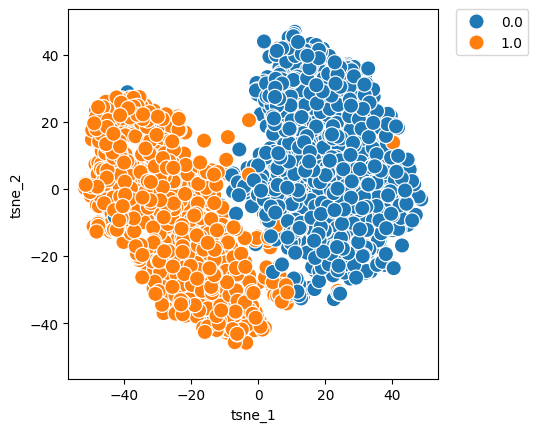

In [ ]:
# Write your code here

### **Testing both networks on translated test set**

In [ ]:
# Write your code here

# **For 10 classes**

In [ ]:
import torchvision
n_epochs = 10
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

In [ ]:
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)) # The values 0.1307 and 0.3081 used for the Normalize() transformation below are the global mean and standard deviation of the MNIST dataset
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)) # The values 0.1307 and 0.3081 used for the Normalize() transformation below are the global mean and standard deviation of the MNIST dataset
                             ])),
  batch_size=batch_size_test, shuffle=True)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 36966012.52it/s]


Extracting /files/MNIST/raw/train-images-idx3-ubyte.gz to /files/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1379347.69it/s]


Extracting /files/MNIST/raw/train-labels-idx1-ubyte.gz to /files/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 9264782.42it/s]


Extracting /files/MNIST/raw/t10k-images-idx3-ubyte.gz to /files/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 2750184.61it/s]

Extracting /files/MNIST/raw/t10k-labels-idx1-ubyte.gz to /files/MNIST/raw



In [ ]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([1000, 1, 28, 28])

### FFNN

In [ ]:
# Write your code here

### CNN

In [ ]:
# Write your code here

### Testing on translated data

In [ ]:
# Write your code here

# Conlcusion
- CNN classification performance is better than FFNN on images
- It used fewer number of parameters than FFNN
